In [1]:
from mpasdiag import MPAS3DProcessor, MPASSurfacePlotter


In [2]:
proc = MPAS3DProcessor(grid_file="../data/grids/x1.10242.static.nc", verbose=True)
proc.load_3d_data("../data/u240k/mpasout")

In [3]:
var_name, level_index, tindex = "qv", 12, 1     # level 0 = surface
data_3d = proc.dataset[var_name].isel(Time=tindex)       # shape (nCells, nVertLevels)
lon, lat = proc.extract_2d_coordinates_for_variable(var_name, data_3d)

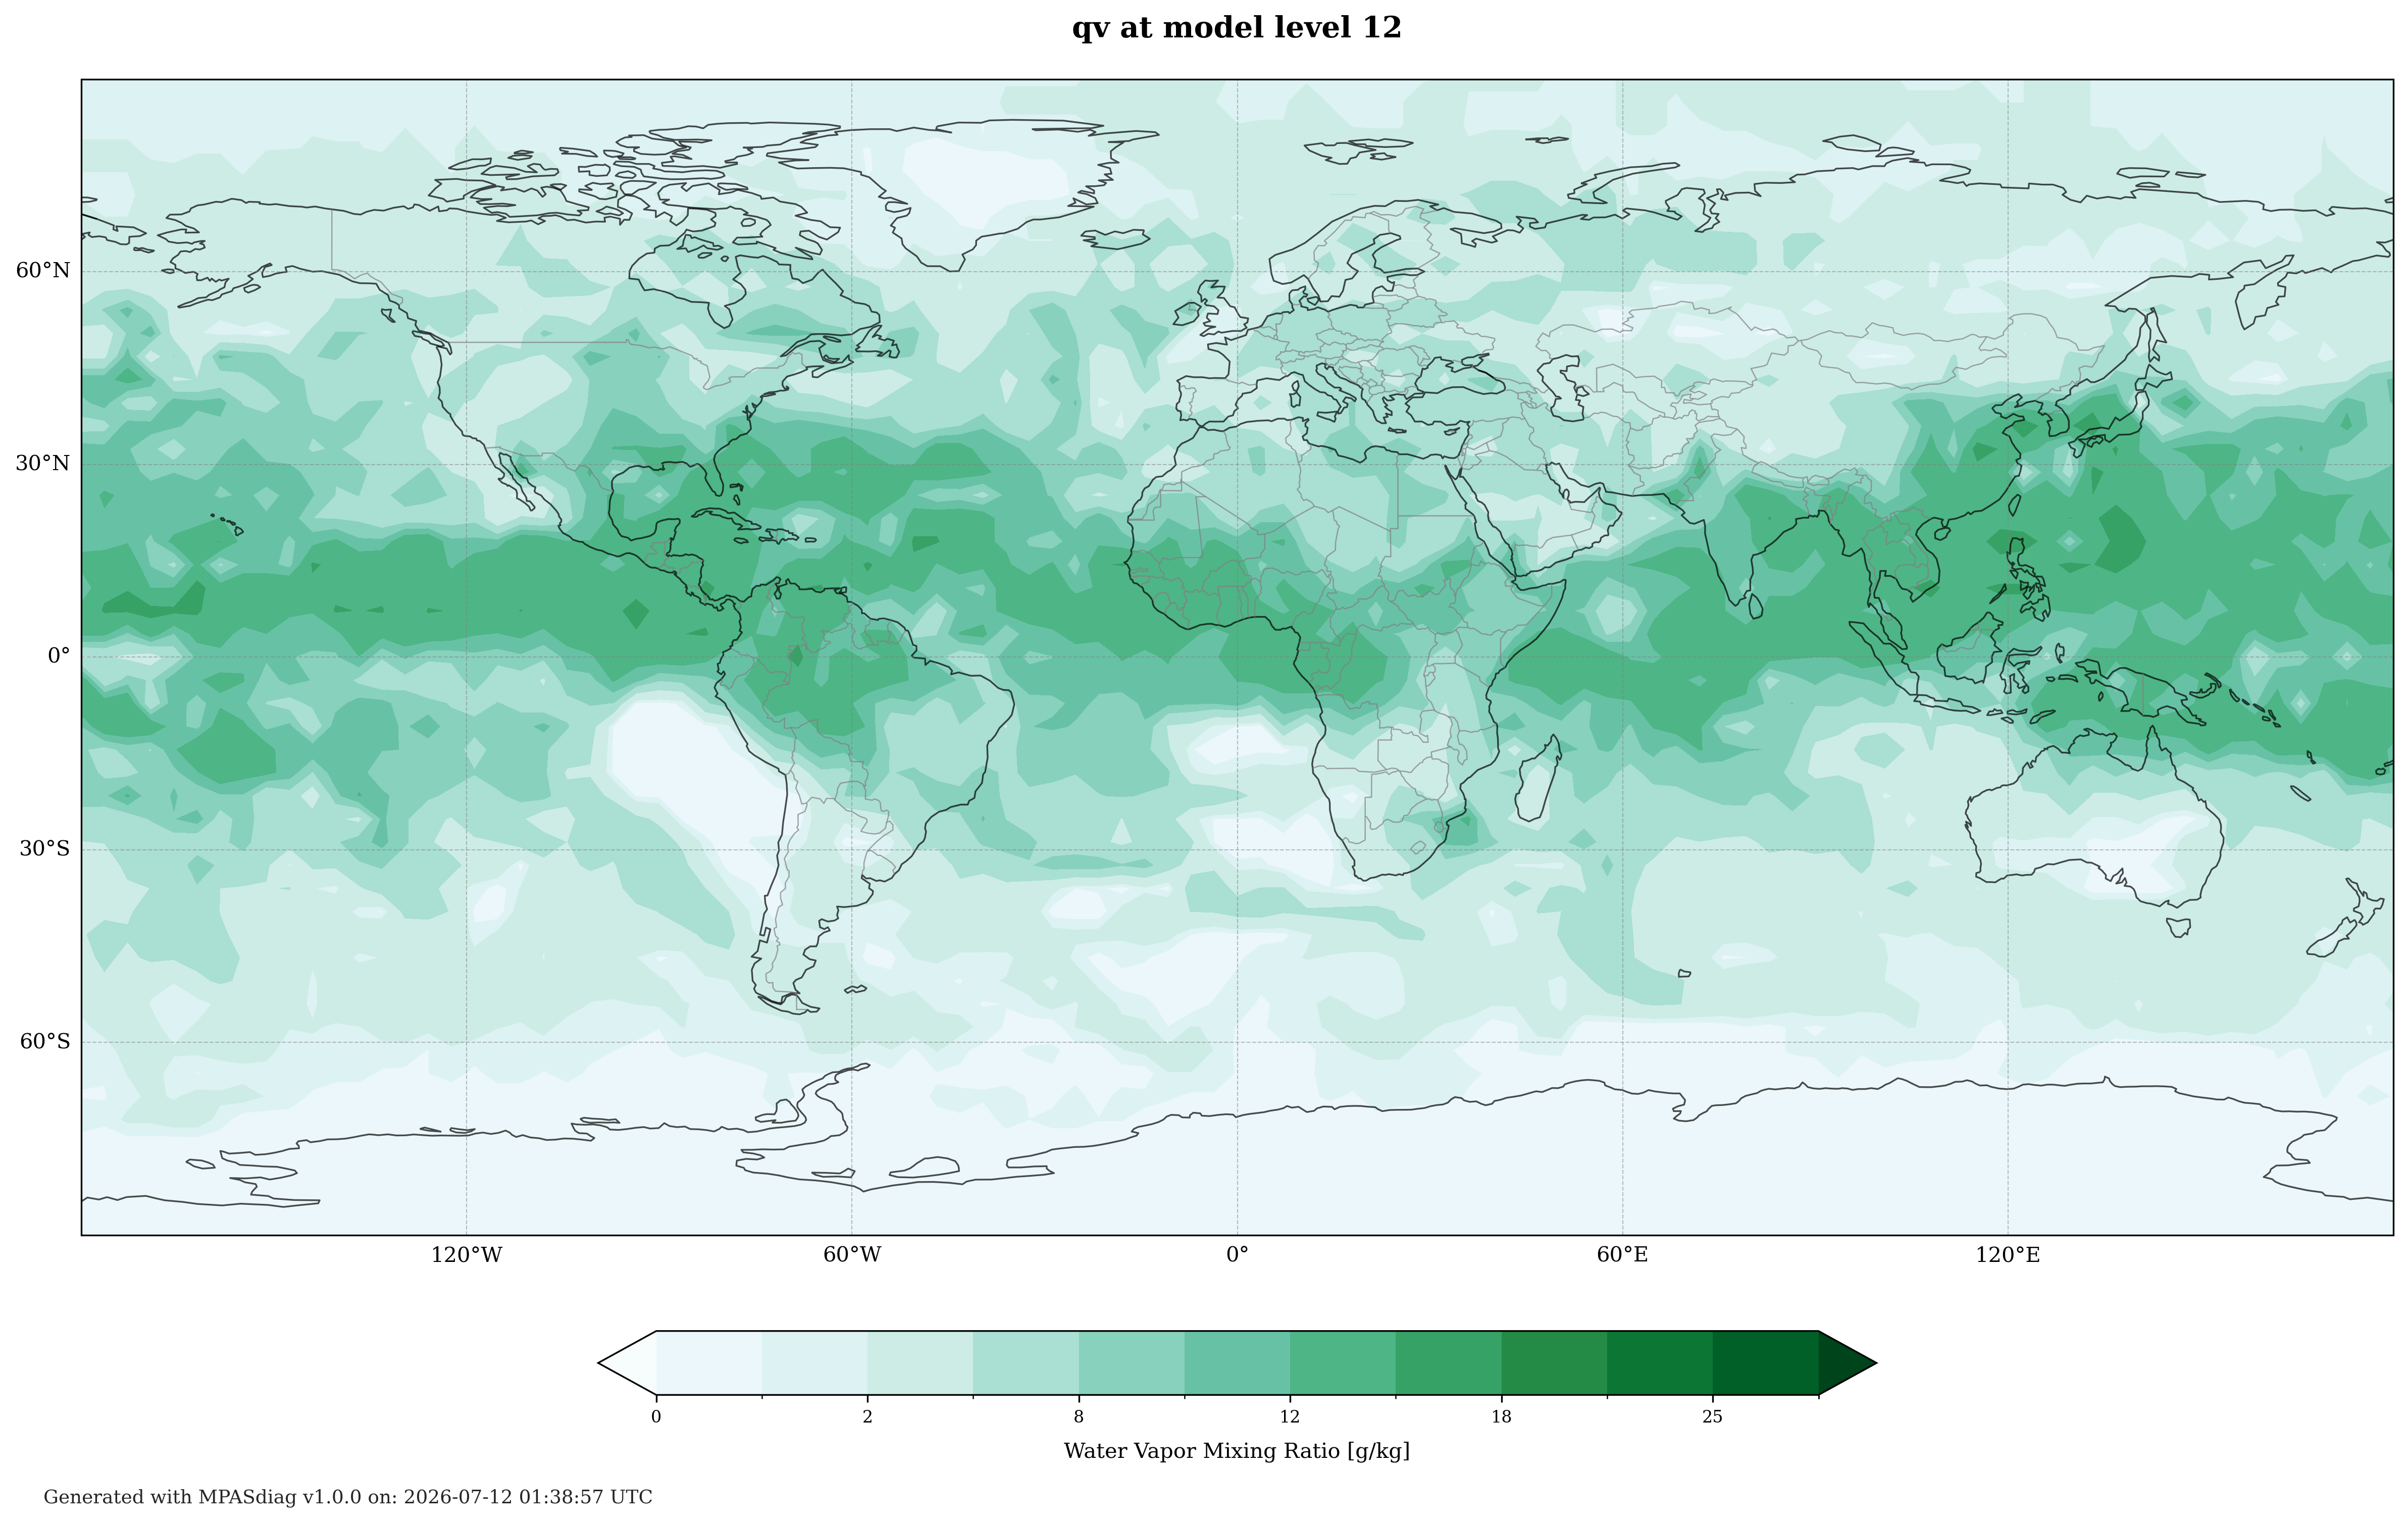

In [4]:
plotter = MPASSurfacePlotter(figsize=(16, 10), dpi=300)
fig, ax = plotter.plot_3d_variable_slice(
    data_array=data_3d, lon=lon, lat=lat, level=level_index,
    var_name=var_name, title=f"{var_name} at model level {level_index}",
)

In [5]:
fig.savefig(f"./output/{var_name}_level{level_index:02d}.png",
            dpi=300, bbox_inches="tight")